 # Regression with a Deep Neural Network

In [70]:
#importing libraries
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import sklearn


In [71]:
np.random.seed(42)
tf.random.set_seed(42)


### Stage 1.1 — Data Loading & Exploratory Data Analysis (EDA)


1.Load & Inspect

In [72]:
#loading dataset
housing_data = sklearn.datasets.fetch_california_housing()

In [73]:
#Feature matrix (X) and target vector (y)
X = housing_data.data
y = housing_data.target

In [74]:
#shape of X and y
print('Shape of Feature matrix :',X.shape)
print('Shape of Target vector :',y.shape)

Shape of Feature matrix : (20640, 8)
Shape of Target vector : (20640,)


In [75]:
#Converting to Dataframe
df = pd.DataFrame(X,columns=housing_data.feature_names)

#creating target column
df['target'] = y

#first 10 rows of df
df.head(10)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


2.Descriptive Statistics

In [76]:
#statistics summary
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [77]:
#outliers checking
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = ((df < lower) | (df > upper))
print(outliers.sum())


MedInc         681
HouseAge         0
AveRooms       511
AveBedrms     1424
Population    1196
AveOccup       711
Latitude         0
Longitude        0
target        1071
dtype: int64


In [78]:
print(df.skew())

MedInc         1.646657
HouseAge       0.060331
AveRooms      20.697869
AveBedrms     31.316956
Population     4.935858
AveOccup      97.639561
Latitude       0.465953
Longitude     -0.297801
target         0.977763
dtype: float64


- Highly Skewed features with extreme values : AveRooms, AveBedrms, and AveOccup
- MedInc : Moderate Skewness
- HouseAge, Latitude, and Longitude are relatively symmetric

3.Visualisations

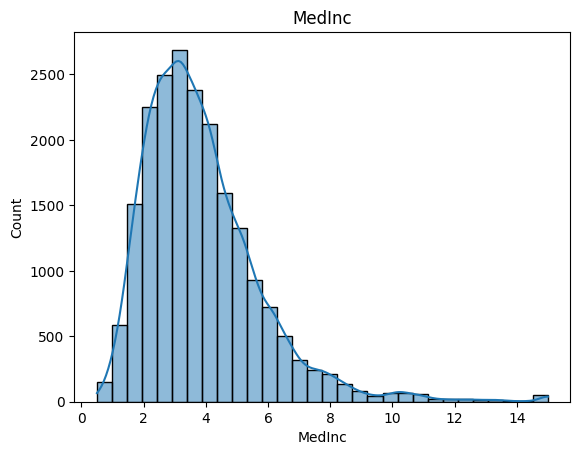

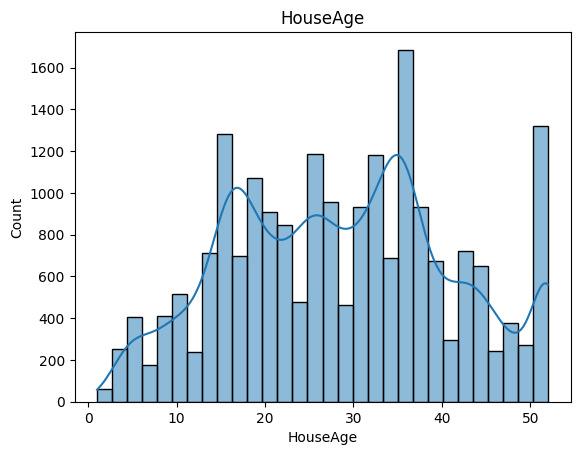

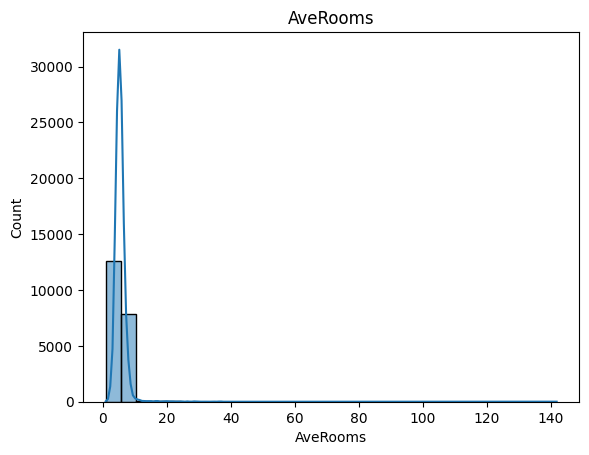

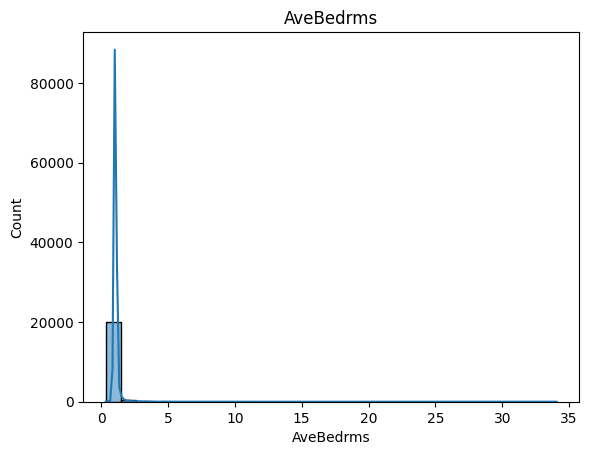

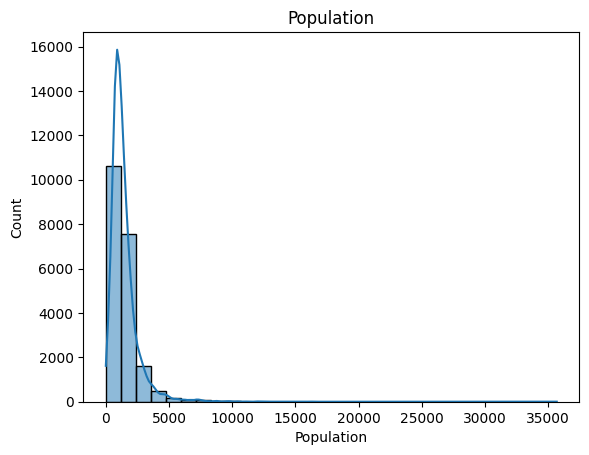

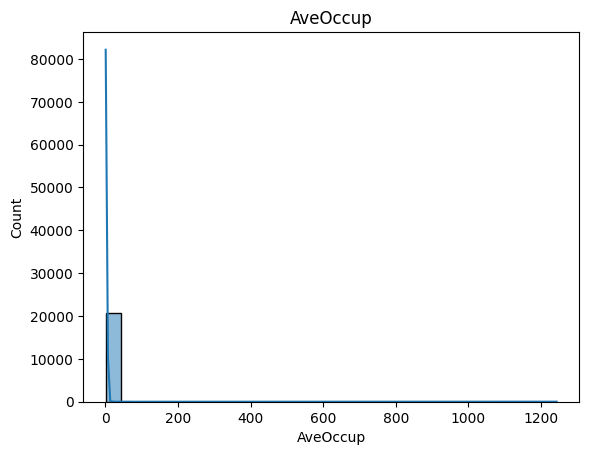

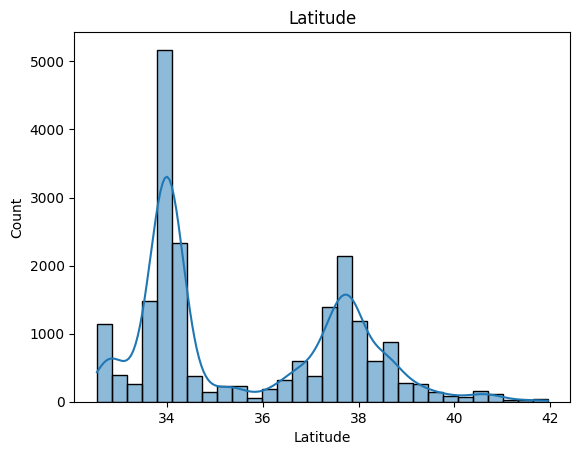

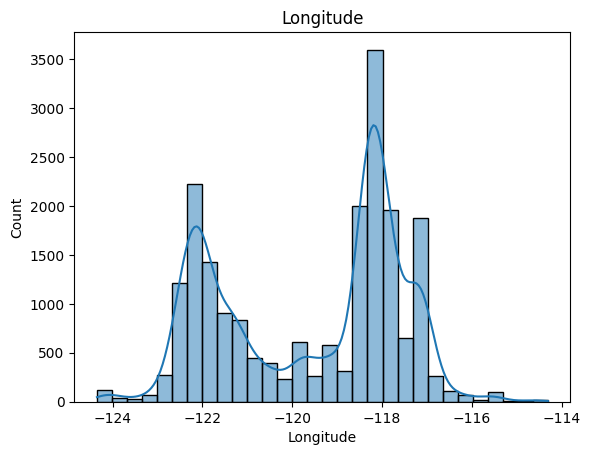

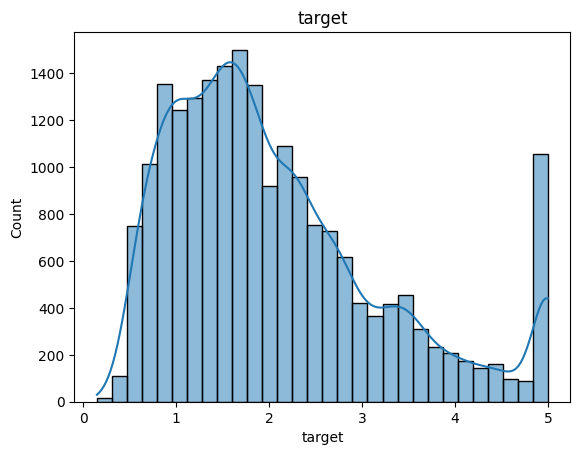

In [79]:
#histogram
for col in df.columns:
  sns.histplot(df[col],bins=30,kde=True)
  plt.title(col)
  plt.show()

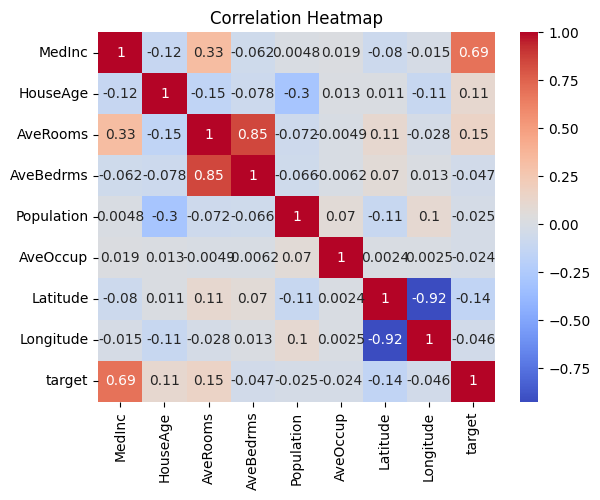

In [80]:
#heatmap
sns.heatmap(df.corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [81]:
#sorting correlation
print(df.corr()['target'].sort_values(ascending=True))

Latitude     -0.144160
AveBedrms    -0.046701
Longitude    -0.045967
Population   -0.024650
AveOccup     -0.023737
HouseAge      0.105623
AveRooms      0.151948
MedInc        0.688075
target        1.000000
Name: target, dtype: float64


- MedInc with strong positive correlation to target
- HouseAge and AveRooms with moderate correlation
- Population , AveBedrms and AveOccup with negative correlation


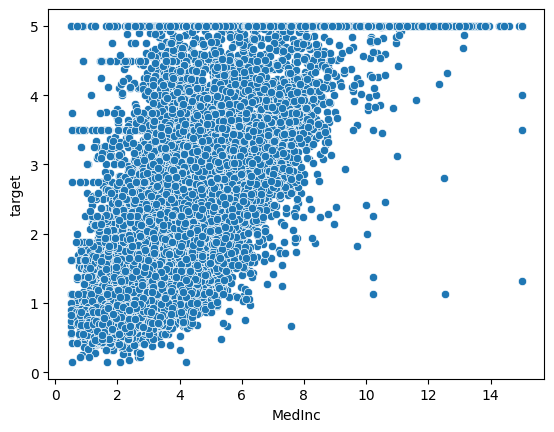

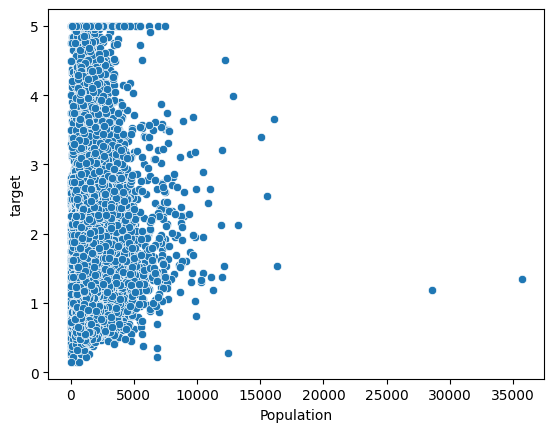

In [82]:
#scatter plots

sns.scatterplot(data=df,x='MedInc',y='target')
plt.show()

sns.scatterplot(data=df,x='Population',y='target')
plt.show()

### Stage 1.2 — Data Preprocessing

4.Train/Validation/Test Split

In [83]:
#spliting data into 70-30 first
from sklearn.model_selection import train_test_split
X = df.drop('target',axis=1)
y = df['target']
# train + temp
X_train,X_temp,y_train,y_temp = train_test_split(X,y,test_size=0.3,random_state=42)
#spliting temp to validation and test
X_val,X_test,y_val,y_test = train_test_split(X_temp,y_temp,test_size=0.5,random_state=42)

- 70% of the data is used so the model has enough data to learn
- 15% of data for validation which is used for hyperparameter tuning
- remaining 15% for testing which is used to evaluate models perfomance in unseen data

5.Feature Scaling

In [84]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

#fitting scaler to train data and transforming train,validation and test data
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

- StandardScaler is used here to scale the features .
- Scaler is only fitted to training data to avoid data leakage.
- If we fit the whole data the model will learn statitical measures from the train ,test and validation data which will cause the model to see test and validation data before training.
- So we fit it in train data to learn statistical measures and apply (transform) it to the train,test & validation data.


### Stage 1.3 — Model Architecture Design
6.Design Your Network

In [85]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,BatchNormalization

#number of input features
input_shape = X_train_scaled.shape[1]

#SequentialModel building
model = Sequential([
    Dense(64,activation='relu',input_shape=(input_shape,)),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32,activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(16,activation='relu'),

    Dense(1)
])

#model summary
print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,585 (14.00 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 192 (768.00 B)

None


- The model consists of three hidden layers with 64, 32, and 16 neurons .
- ReLU activation function is used for non linearity
- Batch Normalization to stabilize the model and Dropout to reduce overfitting.
- Output layer with 1 neuron .

7.Loss Function — Justify Your Choice

- Some features in this dataset contain extreme values so this can influence the model during training if the loss function is sensitive to outliers.
- Huber loss is used here which is a balance of both MAE and MSE . MSE penalise extreme values and MAE evenly treat errors.
- Huber loss acts like MAE when it comes to large error and MSE when it comes to small error which reduce impact of extreme values during training.

8.Performance Metrics — Choose and Justify

- Three regression metrics are selected beyond loss function
- MAE , RMSE , R^2 Score
- MAE shows how much value its off from real value .Loss doesnt give real-world scale of the error
- RMSE ensures the model is not making hude mistakes .
- R2 score shows how good the model is

### Stage 1.4 — Model Training
 9.Compile & Train


In [86]:
from tensorflow.keras import optimizers
optimizer = optimizers.Adam(learning_rate=0.0001)
model.compile(
    optimizer=optimizer, # this updates the weights
    loss='huber', #using huber loss so it keeps extreme values but not get influenced by them
    metrics=['mae']) #evaluation metric to track during training

In [61]:
history = model.fit(X_train_scaled,y_train,epochs=30,batch_size=32,validation_data=(X_val_scaled,y_val))

Epoch 1/30
452/452 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.9989 - mae: 1.4186 - val_loss: 0.5620 - val_mae: 0.9248
Epoch 2/30
452/452 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.4802 - mae: 0.8447 - val_loss: 0.2999 - val_mae: 0.6132
Epoch 3/30
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4030 - mae: 0.7567 - val_loss: 0.2645 - val_mae: 0.5670
Epoch 4/30
452/452 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3627 - mae: 0.7058 - val_loss: 0.2443 - val_mae: 0.5392
Epoch 5/30
452/452 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.3346 - mae: 0.6702 - val_loss: 0.2581 - val_mae: 0.5570
Epoch 6/30
452/452 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.3218 - mae: 0.6563 - val_loss: 0.2251 - val_mae: 0.5123
Epoch 7/30
452/452 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.3043 - mae: 0.6328 - val_loss: 0.2331 - val_mae: 0.5208
Epoch 8/30
452/452 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2951 - mae: 0.6188 - val_loss: 0.2178 - val_mae: 0.5009
Epoch 9/30
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - lo

In [62]:
y_pred = model.predict(X_test_scaled)

97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [63]:
#metrics evaluation
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

print('MAE :',mae)
print('RMSE :',rmse)
print('R^2 :',r2)


MAE : 0.4694384905635971
RMSE : 0.6683777827751681
R^2 : 0.6621603722255682


10.Callbacks


In [64]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

#EarlyStopping
early_stop = EarlyStopping(monitor='val_loss',patience=10, restore_best_weights=True)
#ModelCheckpoint
check_point = ModelCheckpoint("best_regression_model.keras",monitor='val_loss',save_best_only=True,mode='min')

history = model.fit(X_train_scaled,y_train,epochs=100,batch_size=32,validation_data=(X_val_scaled,y_val),callbacks=[early_stop,check_point])

Epoch 1/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2057 - mae: 0.4943 - val_loss: 0.1876 - val_mae: 0.4598
Epoch 2/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2067 - mae: 0.4945 - val_loss: 0.1846 - val_mae: 0.4543
Epoch 3/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2032 - mae: 0.4909 - val_loss: 0.1784 - val_mae: 0.4442
Epoch 4/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.2044 - mae: 0.4909 - val_loss: 0.1769 - val_mae: 0.4416
Epoch 5/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2050 - mae: 0.4918 - val_loss: 0.1971 - val_mae: 0.4768
Epoch 6/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2020 - mae: 0.4875 - val_loss: 0.1869 - val_mae: 0.4592
Epoch 7/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2018 - mae: 0.4877 - val_loss: 0.1934 - val_mae: 0.4701
Epoch 8/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2007 - mae: 0.4867 - val_loss: 0.1847 - val_mae: 0.4551
Epoch 9/100
452/452 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/

- EarlyStopping callback is used which will monitor the validation loss during training and stop training if validation loss does improve for 10 continues epochs which is done to prevent overfitting and improve efficiency.Here the training stopped at epoch 38 .
- ModelCheckpoint is used to monitor the validation loss during training and save the best model

### Stage 1.5 — Plotting & Interpreting Training Curves
11.Training vs. Validation Loss Curve

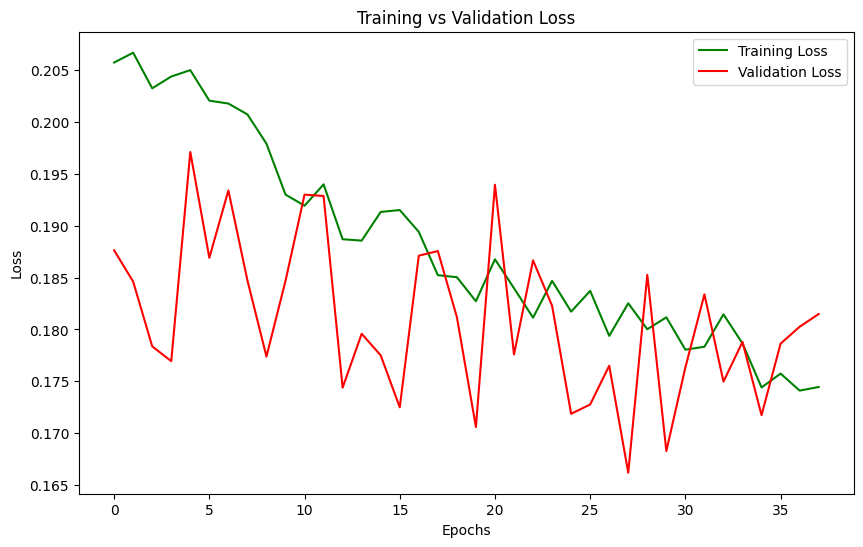

In [65]:
#plot training vs validation loss
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'],label='Training Loss',color='green')
plt.plot(history.history['val_loss'],label='Validation Loss',color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

- The model appears to be well-fitted but validation shows some volatility.
- Convergence : The model starts to converge after epoch 30 and after that the model enters a plateau
- Overfitting : It is not Overfiting.The training loss decreases smoothly, while the validation loss fluctuates but eventually aligns with the training curve.
- Undefitting : Training loss is flattened and doesnt steep down at epoch 38 .
- Effect of callbacks : The training process was stopped at epoch 38 after the validation loss failed to improve .This was appropriate because further training would cause overfitting.
- Recommendations :
  - By adding more hidden layers or trying out different number of neurons
  - Improving training data preprocessing
  - Performing hyperparameter tuning .  

12.Training vs. Validation Metric Curves

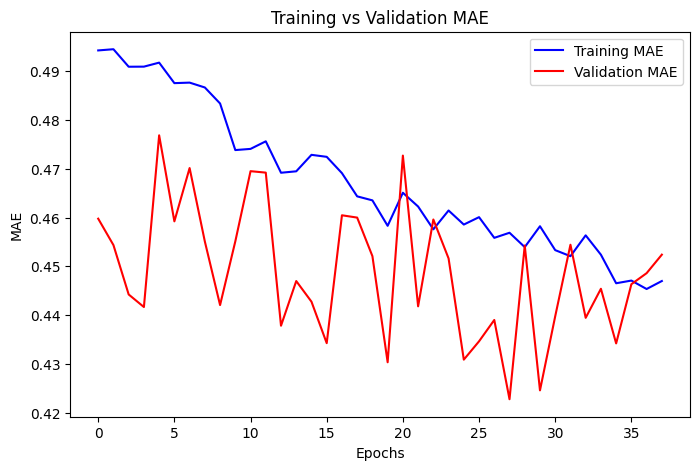

In [66]:
plt.figure(figsize=(8,5))
plt.plot(history.history['mae'],label='Training MAE',color='blue')
plt.plot(history.history['val_mae'],label='Validation MAE',color='red')
plt.xlabel('Epochs')
plt.ylabel('MAE')
plt.title('Training vs Validation MAE')
plt.legend()
plt.show()


- MAE curve is consistent to Loss curve. Both training and MAE decrease during inital epochs which shows efficient learning .This shows the model's perfomance are similar across different evaluation metrics.
- Training Gap :There is gap between training and validation metrics which gradually reduces .This shows generalization improvement overtime and reduced overfitiing.

### Stage 1.6 — Model Evaluation & Analysis
13.Test Set Evaluation


In [67]:
result = model.evaluate(X_test_scaled,y_test)
print('Test Loss :',result[0])
print('Test MAE :',result[1])

97/97 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1542 - mae: 0.4089
Test Loss : 0.154201939702034
Test MAE : 0.4089263677597046


The final model was evaluated on held-out test set . The Test Huber loss and MAE shows the generalization perfomance on unseen data .Since test set was not used in training or validation ,this gives a unbiased evaluation.

14.Prediction Analysis

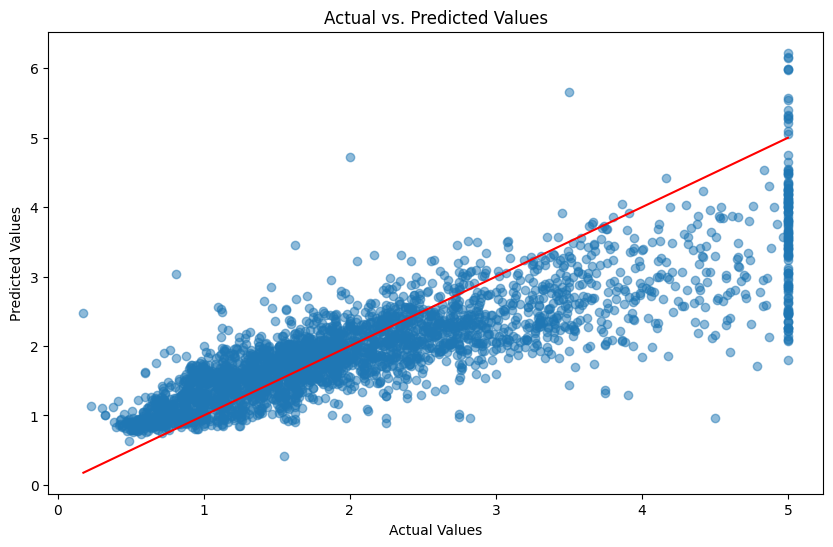

In [68]:
plt.figure(figsize=(10,6))
plt.scatter(y_test,y_pred,alpha=0.5)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.show()

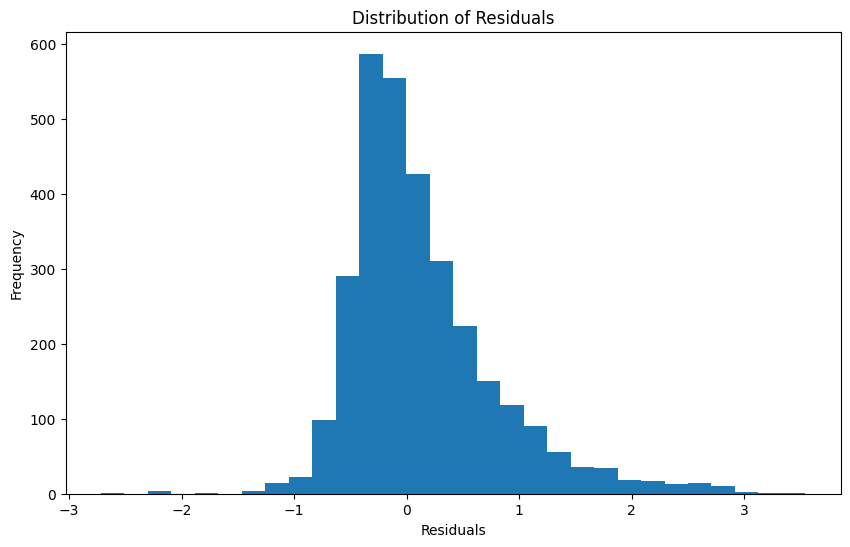

In [69]:
 residuals = y_test - y_pred.flatten()
 plt.figure(figsize=(10,6))
 plt.hist(residuals,bins=30)
 plt.xlabel('Residuals')
 plt.ylabel('Frequency')
 plt.title('Distribution of Residuals')
 plt.show()

- Residuals are centered around zero and gives a roughly symmetric distribution.
- It is observed that error increases as the house value increases . For lower target (approx 0-3) most predicitions are close to reference line . For higher target predictions are dispersed which shows the model struggle with higher target values.

15.Discussion & Reflection

1. This model has a Test MAE of 0.4089 and a Test Loss of 0.1542 and when comparing it with validation metrics it generalizes well .
2. Improvements:
  - Feature Engineering : The model might me struggling at some places due to lack of information . So adding more related features may help model see relationship more clearly.
  - Complexity : By adding more hidden layers or neurons more increase the perfomance.
  - Data - More data can help model learn new patterns , improves generalization
3. Reflect : Tuning learning rate had a huge effect .Initally  learning rate was high and it caused the model to overfit . Later lowering, it stabilized the model but made the r2 score lower which also decreased the variance leading to more reliable model.


